In [1]:
import pandas  as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import mne
import sklearn
#from pandas.core._numba.kernels import mean_

#np.set_printoptions(threshold=np.inf)
#---------------------------------------------Wczytywanie danych--------------------------
raw_data = mne.io.read_raw_edf("data/abc_raw.edf", preload=True, infer_types=True) # załaduj do pamięci, typ EEG do znanych kanałów

Extracting EDF parameters from data/abc_raw.edf...
Channel 'EEG P3-Pz' recognized as type EEG (renamed to 'P3-Pz').
Channel 'EEG C3-Pz' recognized as type EEG (renamed to 'C3-Pz').
Channel 'EEG F3-Pz' recognized as type EEG (renamed to 'F3-Pz').
Channel 'EEG Fz-Pz' recognized as type EEG (renamed to 'Fz-Pz').
Channel 'EEG F4-Pz' recognized as type EEG (renamed to 'F4-Pz').
Channel 'EEG C4-Pz' recognized as type EEG (renamed to 'C4-Pz').
Channel 'EEG P4-Pz' recognized as type EEG (renamed to 'P4-Pz').
Channel 'EEG Cz-Pz' recognized as type EEG (renamed to 'Cz-Pz').
Channel 'EEG A1-Pz' recognized as type EEG (renamed to 'A1-Pz').
Channel 'EEG Fp1-Pz' recognized as type EEG (renamed to 'Fp1-Pz').
Channel 'EEG Fp2-Pz' recognized as type EEG (renamed to 'Fp2-Pz').
Channel 'EEG T3-Pz' recognized as type EEG (renamed to 'T3-Pz').
Channel 'EEG T5-Pz' recognized as type EEG (renamed to 'T5-Pz').
Channel 'EEG O1-Pz' recognized as type EEG (renamed to 'O1-Pz').
Channel 'EEG O2-Pz' recognized as t

In [2]:
print(raw_data) #Informacje o kanałach i objekcie
print("\n#############################################\n")
print(raw_data.info) #Informacje o kanałach i objekcie
print("\n#############################################\n")
print(raw_data.describe()) #Informacje o kanałach i objekcie
print("\n#############################################\n")

<RawEDF | abc_raw.edf, 51 x 5478000 (9130.0 s), ~2.08 GiB, data loaded>

#############################################

<Info | 8 non-empty values
 bads: []
 ch_names: P3-Pz, C3-Pz, F3-Pz, Fz-Pz, F4-Pz, C4-Pz, P4-Pz, Cz-Pz, CM, ...
 chs: 50 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 300.0 Hz
 meas_date: 2026-05-27 11:04:35 UTC
 nchan: 51
 projs: []
 sfreq: 600.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>

#############################################

<RawEDF | abc_raw.edf, 51 x 5478000 (9130.0 s), ~2.08 GiB, data loaded>
ch  name     type  unit        min         Q1     median         Q3        max
 0  P3-Pz    EEG   µV     -1818.28     -36.90      14.40      59.40    1109.99
 1  C3-Pz    EEG   µV     -1694.68     -21.30      25.20      72.60    1607.38
 2  F3-Pz    EEG   µV     -1955.68     -65.40     -17.10      40.50    2846.07
 3  Fz-Pz    EEG   µV     -1369.49     -12.00      34.50      87.00    1064.09
 

C:\Users\Szymon Konarski\AppData\Local\Temp\ipykernel_4516\642906851.py:16: RuntimeWarning: The unit for channel(s) CM, X1:, X2:, X3: has changed from V to NA.
  raw_data.set_channel_types(ch_types)
C:\Users\Szymon Konarski\AppData\Local\Temp\ipykernel_4516\642906851.py:16: RuntimeWarning: The unit for channel(s) Trigger has changed from NA to V.
  raw_data.set_channel_types(ch_types)


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
<Info | 10 non-empty values
 bads: []
 ch_names: P3, C3, F3, Fz, F4, C4, P4, Cz, CM, A1, Fp1, Fp2, T3, T5, O1, ...
 chs: 21 EEG, 4 misc, 2 Stimulus
 custom_ref_applied: True
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 300.0 Hz
 meas_date: 2026-05-27 11:04:35 UTC
 nchan: 27
 projs: []
 sfreq: 600.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>


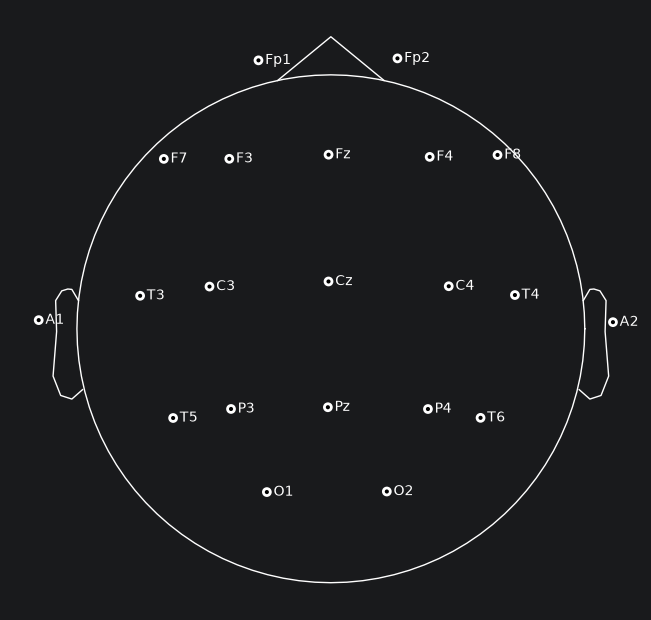

In [2]:
data = raw_data.get_data()

newNames = { ch:ch.split('-')[0].strip() for ch in raw_data.ch_names}
raw_data.rename_channels(newNames)

ch_types = {}
for ch in raw_data.ch_names:
    if ch in ['X1:', 'X2:', 'X3:', 'CM']:
        ch_types[ch] = 'misc'
    elif ch in ['Trigger', 'Event']:
        ch_types[ch] = 'stim'
    elif ch[:3] == "Imp":
        raw_data.drop_channels([ch])
    else:
        ch_types[ch] = 'eeg'
raw_data.set_channel_types(ch_types)

montage = mne.channels.make_standard_montage('standard_1020')
raw_data.set_montage(montage, on_missing='ignore')

raw_data.set_eeg_reference(ref_channels=['A1', 'A2'])
print(raw_data.info)
raw_data.plot_sensors(kind='topomap', show_names=True);

In [ ]:
print(raw_data.describe())

In [3]:
raw_data.drop_channels(['Event']) #Pominiecie elektrod z ktorych jest 0 sygnalu

<RawEDF | abc_raw.edf, 26 x 5478000 (9130.0 s), ~1.06 GiB, data loaded>

Effective window size : 3.413 (s)
Plotting power spectral density (dB=True).


C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Effective window size : 3.413 (s)
Plotting power spectral density (dB=True).


C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


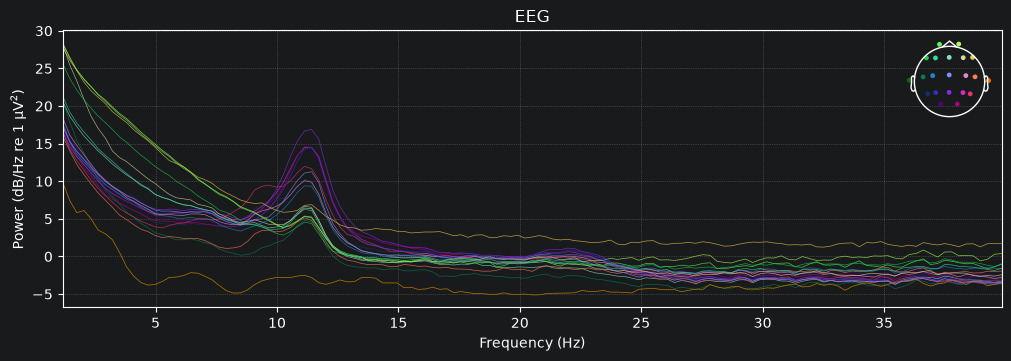

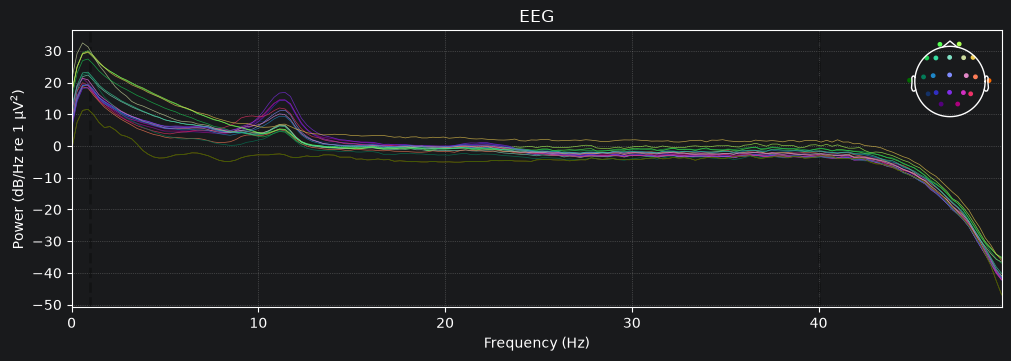

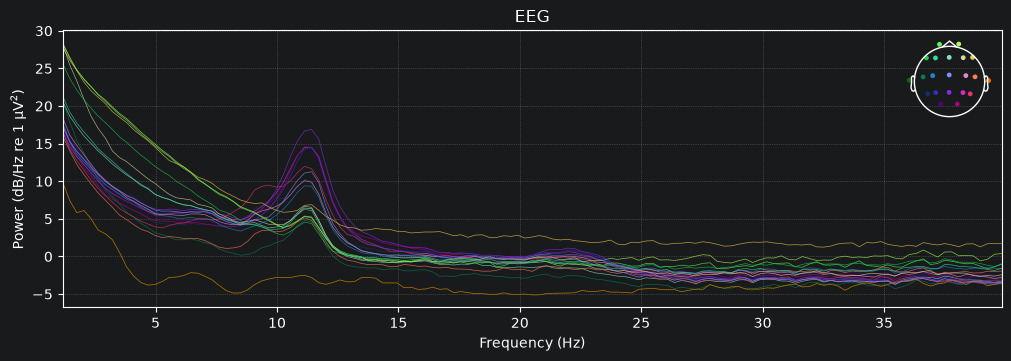

In [4]:
#-------------------------------------Filtrowanie------------------------
raw_data = raw_data.notch_filter(freqs=50, verbose=False)
raw_data = raw_data.filter(l_freq=1, h_freq=40, verbose=False)
#----------------------------------------------------------------------------
raw_data.compute_psd(fmax=50).plot()
raw_data.compute_psd(fmin=1, fmax=40).plot()

In [5]:
#-------------------------Automatyczne wykrywanie złych kanałów na podstawie impedancji----
#Autor: Wojciech Bargiel (z modyfikacjami)

# Podejście hybrydowe:
# 1. Kanały z bardzo dużym udziałem Low_SNR oznaczamy jako "bad"
# 2. Dla pozostałych kanałów tworzymy adnotacje czasowe BAD_*
#    aby odrzucać tylko fragmenty nagrania o złej jakości

df_imp = pd.read_csv("data/abc_imp.csv", skiprows=6)

bad_channels = []
annotations = []

# Kanały pomocnicze - nie analizujemy ich jakości EEG
excluded_imp_channels = ["X1:", "X2:", "X3:", "CM"]

# Kanał uznajemy za martwy jeśli >50% próbek ma Low_SNR
dead_channel_threshold = 0.50

# Maksymalna przerwa (w sekundach) między kolejnymi wpisami Low_SNR,
# aby traktować je jako jeden ciągły fragment
# merge_gap = 1.5 # bezpieczna, stała wartość, gdy kolumna Time jest właśnie próbkowana co 1 sekundę
time_step = df_imp["Time"].diff().median()
merge_gap = time_step * 1.5

for col in df_imp.columns:
    if col == "Time":
        continue
    if col in excluded_imp_channels:
        print(f"{col}: pominięty (kanał pomocniczy)")
        continue

    mask = ( df_imp[col].astype(str).str.strip() == 'Low_SNR')
    low_snr_sum = mask.sum()
    low_snr_ratio = low_snr_sum / len(df_imp)

    print(f"{col}: {low_snr_ratio:.2%} Low_SNR")

    # MARTWY KANAŁ - oznaczamy cały kanał jako bad
    if low_snr_ratio > dead_channel_threshold:
        bad_channels.append(col)
        print(
            f"  -> kanał oznaczony jako BAD "
            f"(Low_SNR = {low_snr_ratio:.2%})"
        )
        continue

    # KANAŁ W WIĘKSZOŚCI DOBRY - tworzymy adnotacje czasowe
    bad_times = df_imp.loc[mask, "Time"].to_numpy()

    if len(bad_times) == 0:
        continue

    start = bad_times[0]
    prev = bad_times[0]

    for current in bad_times[1:]:
        if current - prev > merge_gap:
            annotations.append(
                dict(
                    onset=float(start),
                    duration=float(prev - start + 1),
                    description=f"BAD_{col}"
                )
            )
            start = current
        prev = current
    # ostatni fragment
    annotations.append(
        dict(
            onset=float(start),
            duration=float(prev - start + 1),
            description=f"BAD_{col}"
        )
    )

# Mapowanie nazw kanałów z CSV na nazwy w EDF
bads_in_edf = []
for bad_ch in bad_channels:
    matched = [ch for ch in raw_data.ch_names if bad_ch in ch]
    bads_in_edf.extend(matched)

raw_data.info['bads'] = bads_in_edf
print(f"Updated MNE Raw object. Bad channels: {raw_data.info['bads']}")

# Tworzenie adnotacji MNE
if len(annotations) > 0:
    annot = mne.Annotations(
        onset=[a["onset"] for a in annotations],
        duration=[a["duration"] for a in annotations],
        description=[a["description"] for a in annotations],
        orig_time=raw_data.annotations.orig_time

    )
    raw_data.set_annotations(
        raw_data.annotations + annot
    )
    print(
        f"Dodano {len(annotations)} "
        f"adnotacji związanych z Low_SNR."
    )

# Podgląd
print(raw_data.annotations)

P3: 0.00% Low_SNR
C3: 0.10% Low_SNR
F3: 0.21% Low_SNR
Fz: 0.00% Low_SNR
F4: 0.07% Low_SNR
C4: 0.00% Low_SNR
P4: 0.00% Low_SNR
Cz: 0.00% Low_SNR
A1: 0.84% Low_SNR
Fp1: 0.67% Low_SNR
Fp2: 0.88% Low_SNR
T3: 0.13% Low_SNR
T5: 0.13% Low_SNR
O1: 0.00% Low_SNR
O2: 0.00% Low_SNR
X3:: pominięty (kanał pomocniczy)
X2:: pominięty (kanał pomocniczy)
F7: 0.67% Low_SNR
F8: 0.82% Low_SNR
X1:: pominięty (kanał pomocniczy)
A2: 0.56% Low_SNR
T6: 0.24% Low_SNR
T4: 0.70% Low_SNR
Pz: 0.00% Low_SNR
Updated MNE Raw object. Bad channels: []
Dodano 413 adnotacji związanych z Low_SNR.
<Annotations | 10757 segments: 10 (1320), 11 (1320), 12 (1320), 13 (1320), ...>


Effective window size : 3.413 (s)
Plotting power spectral density (dB=True).


C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


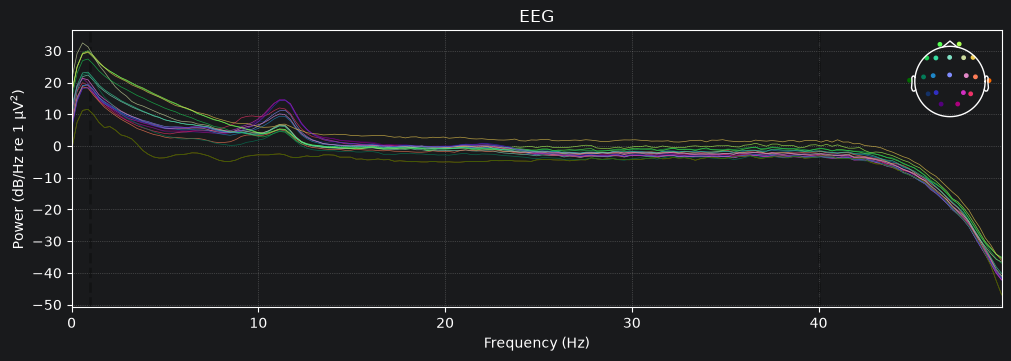

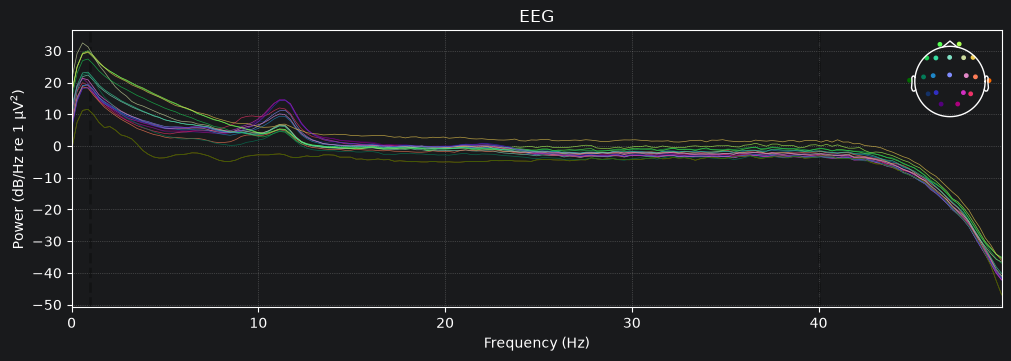

In [30]:
(raw_data.compute_psd(fmax=50, window= "hamming")
 .plot(picks="data", exclude=['X1:', 'X2:', 'X3:', 'CM', 'Ax', 'Ay', 'Az', 'Pz'], amplitude=False))
#raw_data.plot(duration=5, n_channels=21)

In [ ]:
eog_epochs = mne.preprocessing.create_eog_epochs(raw_data, ch_name=["Fp1","Fp2"],
                                                  baseline=(-0.5, -0.2))
eog_epochs.plot_image(combine="mean")
eog_epochs.average().plot_joint()

In [6]:
ica = mne.preprocessing.ICA(
    n_components=0.99,
    method="fastica",
    random_state=42,
    max_iter="auto"
)

print("Dopasowywanie ICA...")
ica.fit(raw_data)

# Wykrywanie komponentów związanych z mrugnięciami (EOG)
eog_inds, scores = ica.find_bads_eog(
    raw_data,
    ch_name=["X1:", "X2:"]
)

print(f"Znalezione komponenty EOG: {eog_inds}")

# Oznaczenie komponentów do usunięcia
ica.exclude.extend(eog_inds)
# Wykrywanie artefaktów mięśniowych
try:
    muscle_inds, muscle_scores = ica.find_bads_muscle(
        raw_data
    )
    print(f"Znalezione komponenty mięśniowe: {muscle_inds}")

    if len(muscle_inds) > 0:
        # UWAGA:
        # Na początku warto obejrzeć komponenty ręcznie
        # przed automatycznym usuwaniem.
        ica.exclude.extend(muscle_inds)
except Exception as e:
    print("Nie udało się wykryć komponentów mięśniowych:")
    print(e)
# Usunięcie wybranych komponentów
print(f"Usuwane komponenty ICA: {ica.exclude}")
raw_data = ica.apply(raw_data.copy())
print("ICA zakończona.")

Dopasowywanie ICA...
Fitting ICA to data using 21 channels (please be patient, this may take a while)
Omitting 185400 of 5478000 (3.38%) samples, retaining 5292600 (96.62%) samples.
Selecting by explained variance: 17 components
Fitting ICA took 878.3s.
Using EOG channels: X1:, X2:
Omitting 185400 of 5478000 (3.38%) samples, retaining 5292600 (96.62%) samples.
Omitting 185400 of 5478000 (3.38%) samples, retaining 5292600 (96.62%) samples.
Omitting 185400 of 5478000 (3.38%) samples, retaining 5292600 (96.62%) samples.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter

C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\time_frequency\psd.py:292: UserWarning: nperseg = 2048 is greater than input length  = 1200, using nperseg = 1200
  return _func(*args, **kwargs)
C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\time_frequency\psd.py:292: UserWarning: nperseg = 2048 is greater than input length  = 600, using nperseg = 600
  return _func(*args, **kwargs)
C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\time_frequency\psd.py:292: UserWarning: nperseg = 2048 is greater than input length  = 600, using nperseg = 600
  return _func(*args, **kwargs)
C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\site-packages\mne\time_frequency\psd.py:292: UserWarning: nperseg = 2048 is greater than input length  = 600, using nperseg = 600
  return _func(*args, **kwargs)
C:\Users\Szymon Konarski\Desktop\pdf\SEM6\BIAI\BIAI_projekt\.venv\Lib\

Znalezione komponenty mięśniowe: [5, 6, 8, 9, 13]
Usuwane komponenty ICA: [5, 6, 8, 9, 13]
Applying ICA to Raw instance
    Transforming to ICA space (17 components)
    Zeroing out 5 ICA components
    Projecting back using 21 PCA components
ICA zakończona.


In [ ]:
ica.plot_components()

In [ ]:
#ica.exclude = [1]
#ica.apply(raw)

In [31]:
print(raw_data.describe)
print(raw_data.info)

<bound method BaseRaw.describe of <RawEDF | abc_raw.edf, 26 x 5478000 (9130.0 s), ~1.06 GiB, data loaded>>
<Info | 11 non-empty values
 bads: 3 items (X3:, X2:, X1:)
 ch_names: P3, C3, F3, Fz, F4, C4, P4, Cz, CM, A1, Fp1, Fp2, T3, T5, O1, ...
 chs: 21 EEG, 4 misc, 1 Stimulus
 custom_ref_applied: True
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 1.0 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-05-27 11:04:35 UTC
 nchan: 26
 projs: []
 sfreq: 600.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>


In [ ]:
print(raw_data.annotations)
print(raw_data.annotations.duration)
print(raw_data.annotations.description)
print(raw_data.annotations.onset)

eventsAD, event_id = mne.events_from_annotations(raw_data)
print(eventsAD.shape, event_id)

Finding events on: Trigger
10345 events found on stim channel Trigger
Event IDs: [  1   2   3   4  10  11  12  13  14  15  16  17  20  21  23  26  30  31
 250]
Liczba wszystkich eventów: 10345


C:\Users\Szymon Konarski\AppData\Local\Temp\ipykernel_4516\3909507599.py:26: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig = mne.viz.plot_events(


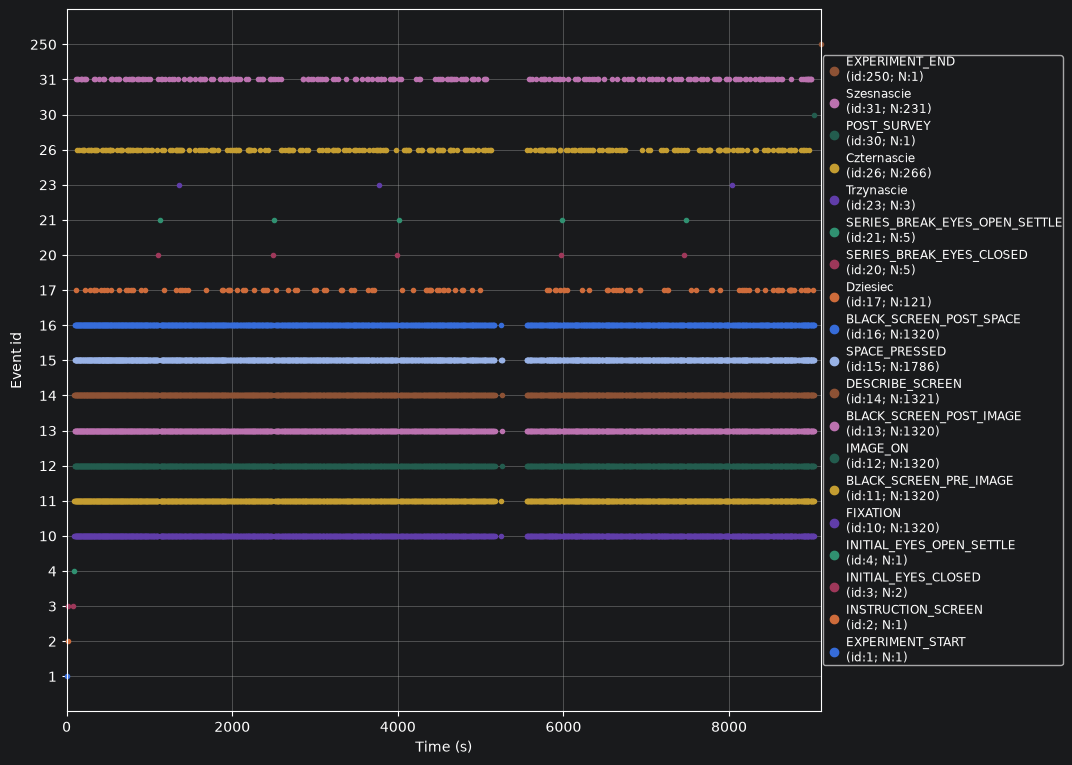

Zapisano pomyślnie do pliku pierwsze_100_eventow.txt!


In [7]:

events = mne.find_events(raw_data, stim_channel="Trigger", initial_event=True, shortest_event=0.5, min_duration=0.001, consecutive=True)

print(f"Liczba wszystkich eventów: {len(events)}")

slownik_event = {
    "EXPERIMENT_START": 1,
    "INSTRUCTION_SCREEN": 2,
    "INITIAL_EYES_CLOSED": 3,
    "INITIAL_EYES_OPEN_SETTLE": 4,
    "FIXATION": 10,
    "BLACK_SCREEN_PRE_IMAGE": 11,
    "IMAGE_ON": 12,
    "BLACK_SCREEN_POST_IMAGE": 13,
    "DESCRIBE_SCREEN": 14,
    "SPACE_PRESSED": 15,
    "BLACK_SCREEN_POST_SPACE": 16,
    "Dziesiec": 17,
    "SERIES_BREAK_EYES_CLOSED": 20,
    "SERIES_BREAK_EYES_OPEN_SETTLE": 21,
    "Trzynascie": 23,
    "Czternascie": 26,
    "POST_SURVEY": 30,
    "Szesnascie": 31,
    "EXPERIMENT_END": 250
}
fig = mne.viz.plot_events(
    events, sfreq=raw_data.info["sfreq"], first_samp=raw_data.first_samp, event_id=slownik_event
)

np.savetxt( "pierwsze_100_eventow.txt", events[:200],fmt="%d",
            header="Sample_Number | Duration | Event_ID" )
print("Zapisano pomyślnie do pliku pierwsze_100_eventow.txt!")

#epochs = mne.Epochs(raw, events, event_id=2, tmin=-1, tmax=2, baseline=(-0.5, 0),
 #                   preload=True, reject=dict(eeg=2e-4))



Liczba IMAGE_ON: 1320


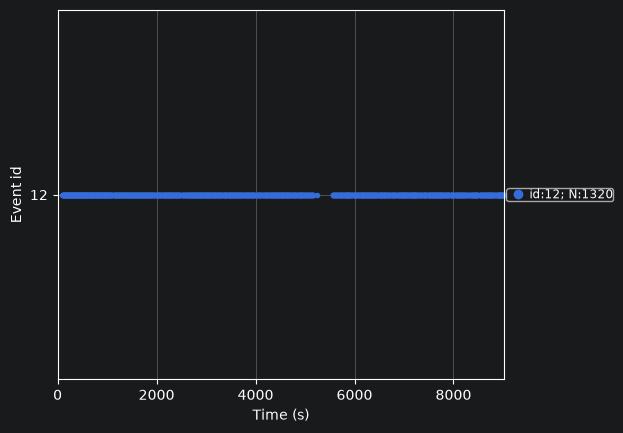

In [8]:
# Filtrtacja eventów IMAGE_ON (kod = 12)
imageOn_events = events[(events[:, 2] == 12)]
print(f"Liczba IMAGE_ON: {len(imageOn_events)}")
fig = mne.viz.plot_events(
    imageOn_events, sfreq=raw_data.info["sfreq"], first_samp=raw_data.first_samp
)

In [9]:
# Wczytanie danych z pliku events_csv
events_csv = pd.read_csv("abc_EEGBasedVisualRecall_Events_Rep1_2026-05-27_11-04-56.csv")
# Wyciagniecie z events_csv tylko rekordów IMAGE_ON
image_events_csv = ( events_csv.query("event_code == 12").reset_index(drop=True) )

print( f"Liczba IMAGE_ON w CSV: {len(image_events_csv)}")

# Kontrola zgodności image_events z image_events_csv
assert len(imageOn_events) == len(image_events_csv), \
    "Liczba eventów IMAGE_ON w EEG i w CSV nie jest taka sama!"

Liczba IMAGE_ON w CSV: 1320


In [10]:

# Utworzenie metadanych dla epok
metadata = image_events_csv[
    [ "participant_id", "series_id", "trial_id",
        "image_id","image_category","image_file" ]
].copy()
# Definicja event_id
event_id = {"IMAGE_ON": 12}

# Tworzenie epok
# ------------------------------------------------------------
# t = 0      -> pojawienie się obrazka
# t = -0.35   -> 350 ms przed obrazkiem
# t = 1.0    -> 1000 ms po obrazku
# ------------------------------------------------------------
epochs = mne.Epochs(
    raw_data,
    imageOn_events,
    event_id=event_id,
    tmin=-0.35,
    tmax=0.5,
    baseline=(-0.35, -0.01),
    metadata=metadata,
    preload=True,
    reject_by_annotation=True # odrzucenie epok z adnotacjami BAD_
)
print(epochs)

# Podglad pierwszych epok
print(epochs.metadata.head())

usuniete = [idx for idx, log in enumerate(epochs.drop_log) if len(log) > 0]
print(f"Lista usuniętych epok: {(usuniete)}")

Adding metadata with 6 columns
1320 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1320 events and 511 original time points ...
55 bad epochs dropped
<Epochs | 1265 events (all good), -0.35 – 0.5 s (baseline -0.35 – -0.01 s), ~128.3 MiB, data loaded, with metadata,
 'IMAGE_ON': 1265>
  participant_id  series_id  trial_id                    image_id  \
0            abc        1.0       1.0   train_126973_000000126973   
1            abc        1.0       2.0    zebra_22815_000000022815   
2            abc        1.0       3.0    boat_140426_000000140426   
3            abc        1.0       4.0    train_44160_000000044160   
4            abc        1.0       5.0  person_330348_000000330348   

  image_category                      image_file  
0          train   train/126973_000000126973.jpg  
1          zebra    zebra/22815_000000022815.jpg  
2           boat    boat/140426_000000140426.jpg  
3          train

In [11]:

# Klasyfikacja kategorii:
y_category = epochs.metadata["image_category"]

# Klasyfikacja konkretnego obrazka:
y_image = epochs.metadata["image_id"]

print("Category y")
print(y_category.head())
print(y_category.shape)
print("Image y")
print(y_image.head())

Category y
0     train
1     zebra
2      boat
3     train
4    person
Name: image_category, dtype: str
(1265,)
Image y
0     train_126973_000000126973
1      zebra_22815_000000022815
2      boat_140426_000000140426
3      train_44160_000000044160
4    person_330348_000000330348
Name: image_id, dtype: str


In [26]:
print(epochs.get_data().shape)

(1265, 26, 511)


In [12]:
#TFA używając CWT (Ciągła analiza falkami MORLETA)

czestotliwosci = np.arange(4,45, 1)
l_cykli = czestotliwosci/4


tfa = epochs.compute_tfr(method="morlet", freqs=czestotliwosci, n_cycles=l_cykli, decim=1, picks='eeg', return_itc=False)

In [13]:
tfa.apply_baseline(baseline=(-0.3, -0.05), mode='zlogratio')
#ratio, logratio, zlogratio, mean, zscore
tfData = tfa.crop(tmin=0.0, tmax=0.5).get_data()

tfData_float32 = tfData.astype(np.float32)

print(tfData_float32)
#srednia = np.mean(tfData_float32, axis=1, keepdims=True)
#tfData_float32 = tfData_float32-srednia

Applying baseline correction (mode: zlogratio)
[[[[ 9.23246324e-01  8.66490006e-01  8.05291951e-01 ... -2.96725130e+00
    -2.80066681e+00 -2.64158726e+00]
   [ 4.32586610e-01  3.47174972e-01  2.56215334e-01 ... -3.88048744e+00
    -3.69839549e+00 -3.52381873e+00]
   [-7.69796133e-01 -8.59596252e-01 -9.53005493e-01 ... -3.92796326e+00
    -3.77061939e+00 -3.62124228e+00]
   ...
   [-1.04941130e+00 -1.08009791e+00 -1.11372113e+00 ...  5.98682702e-01
     5.88934720e-01  5.77593803e-01]
   [-9.46878314e-01 -9.79508162e-01 -1.01573062e+00 ...  5.27841091e-01
     5.21475732e-01  5.13786733e-01]
   [-1.48170960e+00 -1.53436029e+00 -1.59272802e+00 ...  8.79290462e-01
     8.72947454e-01  8.64464700e-01]]

  [[-1.61496222e+00 -1.69318485e+00 -1.77119708e+00 ... -1.05080783e+00
    -1.12213862e+00 -1.19826007e+00]
   [-1.69977105e+00 -1.75864863e+00 -1.81624854e+00 ... -9.38345492e-01
    -1.00027990e+00 -1.06613505e+00]
   [-1.72021580e+00 -1.75657630e+00 -1.79167414e+00 ... -7.30373859e-01


In [14]:
tfData_float32 = 3 - tfData_float32
print(tfData_float32)

[[[[  2.0767536    2.13351      2.194708   ...   5.9672513
      5.800667     5.6415873 ]
   [  2.5674133    2.652825     2.7437847  ...   6.8804874
      6.6983957    6.523819  ]
   [  3.7697961    3.8595963    3.9530056  ...   6.9279633
      6.7706194    6.6212425 ]
   ...
   [  4.0494113    4.080098     4.113721   ...   2.4013174
      2.4110653    2.4224062 ]
   [  3.9468784    3.9795082    4.015731   ...   2.472159
      2.4785242    2.4862132 ]
   [  4.4817095    4.5343604    4.592728   ...   2.1207094
      2.1270525    2.1355352 ]]

  [[  4.614962     4.693185     4.7711973  ...   4.050808
      4.1221385    4.1982603 ]
   [  4.699771     4.758649     4.8162484  ...   3.9383454
      4.00028      4.066135  ]
   [  4.720216     4.7565765    4.791674   ...   3.7303739
      3.7798567    3.8323996 ]
   ...
   [  4.381487     4.290851     4.2047977  ...   2.3593328
      2.3732488    2.3891578 ]
   [  4.27069      4.194002     4.121335   ...   2.5025592
      2.512426     2.524054

In [15]:
print(y_category[90:100])
print(tfData.shape)
print(tfData)
print("\n")
print(tfData_float32.shape)
print(np.min(tfData_float32))
print(y_category.shape)
print(y_image.shape)

91         bird
92     airplane
93        train
94     airplane
95     airplane
96       person
98        apple
100        bird
101       zebra
102       zebra
Name: image_category, dtype: str
(1265, 21, 41, 301)
[[[[ 9.23246303e-01  8.66489995e-01  8.05291946e-01 ... -2.96725121e+00
    -2.80066673e+00 -2.64158721e+00]
   [ 4.32586623e-01  3.47174972e-01  2.56215346e-01 ... -3.88048747e+00
    -3.69839540e+00 -3.52381866e+00]
   [-7.69796162e-01 -8.59596262e-01 -9.53005470e-01 ... -3.92796315e+00
    -3.77061932e+00 -3.62124237e+00]
   ...
   [-1.04941132e+00 -1.08009789e+00 -1.11372117e+00 ...  5.98682713e-01
     5.88934709e-01  5.77593817e-01]
   [-9.46878288e-01 -9.79508141e-01 -1.01573063e+00 ...  5.27841101e-01
     5.21475728e-01  5.13786705e-01]
   [-1.48170956e+00 -1.53436033e+00 -1.59272807e+00 ...  8.79290481e-01
     8.72947453e-01  8.64464712e-01]]

  [[-1.61496221e+00 -1.69318488e+00 -1.77119707e+00 ... -1.05080780e+00
    -1.12213865e+00 -1.19826003e+00]
   [-1.69977105

In [15]:
np.save("Dane32PrzetworzoneNOAVGNOCLIP.npy", tfData_float32)
np.save("EtykietyDanych.npy", y_category)

In [ ]:
# Pojedynczy obrazek dla jednej epoki dla jednego kanału
epoka=14
kanal=14

jedenWynik = tfData[epoka, kanal, :, :]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(jedenWynik, cmap="jet", aspect="auto", origin="lower")

ax.set_title(f"Epoka {epoka}, Kanał {kanal}")
ax.set_xlabel("Punkty czasu")
ax.set_ylabel("Indeksy częstotliwości")
fig.colorbar(im, label="Moc sygnału")

#plt.savefig(f"spektrogram_epoka_{epoka}.png", dpi=100, bbox_inches="tight")
plt.show()
plt.close()

print("Obrazek PNG został zapisany!")
#tfaa=tfa.average()
 #tfaa.plot(picks="O1")

In [17]:
import io
import imageio.v3 as iio
import matplotlib.pyplot as plt
from datetime import datetime

now = datetime.now().strftime("%m%d_%H%M")

In [ ]:
#GIF dla jednego kanału z róznych epok po kolei
nr_kanalu = 14
frames = []

for nr_epoki in range(200):
    fig, ax = plt.subplots(figsize=(8, 6))

    single_spectrogram = tfData[nr_epoki, nr_kanalu, :, :]
    ax.imshow(single_spectrogram, cmap="jet", aspect="auto", origin="lower")
    ax.set_title(f"Epoka: {nr_epoki}")

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)

    frames.append(iio.imread(buf))
    plt.close(fig)

# duration=1000 sekudna na klatke
iio.imwrite("animacja_epok.gif", frames, duration=250, loop=0)

print("GIF utworzony!")

In [ ]:
#GIF dla jednego knału z epok posortowanych według obrazka
sort_indek = np.argsort(y_image)

nr_kanalu = 14
frames = []

for nrKlatki,nr_epoki in enumerate(sort_indek[120:1199]):
    fig, ax = plt.subplots(figsize=(8, 6))

    single_spectrogram = tfData[nr_epoki, nr_kanalu, :, :]

    obecnyobraz= y_image[nr_epoki]

    ax.imshow(single_spectrogram, cmap="jet", aspect="auto", origin="lower")
    ax.set_title(f"Kanał: {raw_data.ch_names[nr_kanalu]} "
                 f"Epoka: {nr_epoki} Obraz {obecnyobraz}")

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)

    frames.append(iio.imread(buf))
    plt.close(fig)

# duration=1000 sekudna na klatke
iio.imwrite("animacja_epok.gif", frames, duration=400, loop=0)

print("GIF utworzony!")

In [18]:
#GIF dla elektrod F3, F4, C3, C4 O1, O2 dla posortoawnych obrazków

y_cat_np = y_category.to_numpy()
y_img_np = y_image.to_numpy()
sort_indek = np.argsort(y_img_np)

frames = []
kanalyL = [2,1,14]
kanalyP = [4,5,15]

warunek_zm = y_cat_np[sort_indek[:-1]] != y_cat_np[sort_indek[1:]]
p_zmiany = np.where(warunek_zm)[0] + 1
granice = [0] + list(p_zmiany) + [len(sort_indek)]

for i in range(0,len(granice)-1):
    print(y_cat_np[sort_indek[granice[i]]] )
obKat = 10
for nrKlatki,nr_epoki in enumerate(sort_indek[granice[obKat]:granice[obKat+1]]):
    fig, ax = plt.subplots(3, 2, figsize=(8, 6))

    obecnyobraz= y_img_np[nr_epoki]

    for idy, nr_kanalu in enumerate(kanalyL):
        single_spectrogram = tfData_float32[nr_epoki, nr_kanalu, :, :]

        ax[idy,0].imshow(single_spectrogram, cmap="jet", aspect="auto", origin="lower")
        ax[idy,0].set_title(f"Kanał: {raw_data.ch_names[nr_kanalu]} ")

    for idy, nr_kanalu in enumerate(kanalyP):
        single_spectrogram = tfData_float32[nr_epoki, nr_kanalu, :, :]

        ax[idy,1].imshow(single_spectrogram, cmap="jet", aspect="auto", origin="lower")
        ax[idy,1].set_title(f"Kanał: {raw_data.ch_names[nr_kanalu]}")

    fig.suptitle(f"Obraz {obecnyobraz}", fontsize=10, fontweight='bold')
    ax[2,1].set_xlabel("Czas")
    ax[1,0].set_ylabel("Częstotliwość")
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100)
    buf.seek(0)

    frames.append(iio.imread(buf))
    plt.close(fig)

# duration=1000 sekudna na klatke
iio.imwrite(f"animacja_epokKanalow_{now}.gif", frames, duration=600, loop=0)

print("Piękny GIF utworzony!")

abstract
airplane
apple
banana
bird
boat
car
dog
person
train
zebra
Piękny GIF utworzony!


In [2]:
# Definiujemy maksymalna dopuszczalna amplitude (150 uV)
#reject_criteria = dict(eeg=150e-6)

# Usuwamy epoki, w ktorych napiecie przekroczylo ustalony prog (artefakty)
#print("Czyszczenie epok z artefaktow (np. mrugania)...")
#epochs.drop_bad(reject=reject_criteria)

#print(f"\nPomyślnie wycięto i oczyszczzono, zostało {len(epochs)} epok")

#epochs.avarage().plot()
#plt.show()



['abc', 'miguel']
